# EBRAINS demonstrator: Sensorimotor neurocontroller

In this tutorial, we progressively explore a **biologically grounded**, **spiking**, **closed-loop neurocontroller** designed to **investigate adaptive sensorimotor behavior** in a **multiple-target reaching task** under **multiple perturbation forces**. The system is designed to **represent different brain areas and their interactions** during the execution of the task, continuosly integrating sensorimotor inputs from the body, namely sensory feedback data, with internally generated neural signals to regulate the movement of a robotic limb in a simulated environment. 

The notebook **introduces** the controller's components **step by step**, starting from its **overall architecture**, and progressively moving toward the **individual neural circuits** and **their interactions**. Through a series of examples and simulations, we will examine the implementation choises done for the activity of each brain region inserted, how neural activity evolves across trials, and ... 

### Learning objectives

After completing this notebook you will be able to:

- Understand the motivation behind the model.
- Configure a motor-learning experiment.
- Visualize the generated planner trajectories.
- Train the recurrent M1 network.
- Interpret the diagnostic figures.
- Evaluate the trained model in inference mode. 

CAMBIALI QUESTI A SECONDA DI QUELLA CHE VUOI FARE

## Table of content 

# Introduction

**Motor control** is a complex function emerging from the coordinated activity of multiple areas of the central nervous system (CNS). Among these regions, the **cerebellum** acts as the ***puppet master***: it integrates heterogeneous sensory and motor inputs from various brain areas, building an **internal representation of body–environment interactions**. This representation takes the form of **internal models**: neural constructs that capture the relationship between motor commands and their expected sensory consequences. Through this process, the cerebellum learns to **predict the sensorimotor consequences** of a movement, enabling **predictive** rather than reactive **movement generation**.

<div style="display: flex; justify-content: center; gap: 20px; align-items: center;">
    <img src="notebooks/imgs/human_movement_without_writings.jpg" width="28%">
    <img src="notebooks/imgs/motor_control_pathways.jpg" width="35%">
</div>

A comprehensive understanding of these mechanisms requires **linking cerebellar neural dynamics to motor behavior**, effectively bridging computational models of neural activity with the physical actions that emerge from them. 
**Neurocontroller** development offers a principled way to build this bridge, providing a framework in which neural dynamics can be directly related to their behavioral output.

## Neurocontroller architecture

The proposed neurocontroller integrates an **AI-based Planner**, representing the premotor cortex within the motor control loop; a **spiking cortical circuit**, embodying the role of the motor cortex (M1); and **two Spiking Neural Network cerebellar circuits**, implementing a forward and an inverse internal model, respectively. This system operates in a closed-loop with a **one degree of freedom virtual limb** through the **NeuroRobotic Platform (NRP)**.

<div style="display: flex; justify-content: center; align-items: center;">
    <img src="notebooks/imgs/controller_with_subdivitions.jpg" width="50%">
</div>

| MODULE | FRAMEWORK | ROLE | LEARNING |
|:---:|:---:|:---:|:---:|
| **Planner** | PyTorch | Object recognition and trajectory generation based on visual input | Learn **offline** through GLE strategy (biologically plausible approximation of backpropagation)  
| **Motor Cortex** | NEST | Generation of motor commands needed to execute a trajectory | Learn **offline** through e-prop (eligibility propagation) strategy (biologically plausible approximation of backpropagation)  
| **Cerebellar models** | NEST | Sensorimotor prediction based on error-driven learning |Learn **online** within each trial through synaptic weights evlution; weights persist across chained trials | Network pre-compiled by BSB (Brain Scaffold Builder) framework into an HDF5 topology and instantiated at run setup 
| **Plant (Robotic embodiment)** | PyBullet | Simulation of a robotic arm with 1-DoF (elbow flexion and extention); rendered-view fidelity for planner visual input | \ |

# Premotor Cortex (PMC)

## 1. Setup

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pybullet as p
from pathlib import Path
from PIL import Image
import random
import math
from pfc_planner.trajectory_generators import MinJerkTrajectoryGenerator
from pfc_planner.planners import GLEPlanner, GLEVisionNet
from pfc_planner.config import default_params
from pfc_planner.factory import get_planner

params = default_params

# URDF assets ship inside the controller package:
# controller/src/neurocontroller/embodiment_assets/{skeleton.urdf, plane.urdf}
ASSETS_DIR = Path("src/neurocontroller/embodiment_assets")
PLANNER_MODEL_DIR = Path("submodules/pfc_planner/models")

SHOULDER_JOINT, ELBOW_JOINT, HAND_LINK = 0, 1, 3
TARGET_COLOR = {"blue": (0, 0, 1, 1), "red": (1, 0, 0, 1)}  # BLUE_LEFT / RED_RIGHT

## 2. Data creation and visualization

In [10]:
def render_scene(init_angle_deg, target_angle_deg, color_label,
                  target_visual_offset_deg=4.0, image_path="input_image.bmp"):

    client = p.connect(p.DIRECT) # DIRECT runs the physics engine in-process with no interactive visualization
    p.setGravity(0, 0, 0, physicsClientId=client)          # ExperimentParams.enable_gravity=False by default
    p.setAdditionalSearchPath(str(ASSETS_DIR), physicsClientId=client)  # set the path where take the models 

    ## LOAD THE 1-DoF ARM MODEL & SET IT IN THE SPACE

    # NOTE: We set useFixedBase in order to keep the robot's torso locked in a specific
    # position, rather than letting it translate and tumble freely through space
    # (like a physical object dropped into the scene).
    robot = p.loadURDF("skeleton.urdf", useFixedBase=True, physicsClientId=client) 
    p.resetBasePositionAndOrientation(robot, [0, 0, 0], [0, 0, 0, 1], physicsClientId=client)

    # remove the implicit default motor, set by PyBullet to every revolute/prismatic joint the moment a model is loaded
    # NOTE:  we want to remove it in order to move the joints as we want, without resistence of their own
    p.setJointMotorControlArray(robot, [SHOULDER_JOINT, ELBOW_JOINT],
                                 p.POSITION_CONTROL, forces=[0, 0], physicsClientId=client)
    p.setJointMotorControlArray(robot, [SHOULDER_JOINT, ELBOW_JOINT],
                                 p.VELOCITY_CONTROL, forces=[0, 0], physicsClientId=client)

    ## LOAD A FLAT PLANE & PLACE IT 
    plane = p.loadURDF("plane.urdf", useFixedBase=True, physicsClientId=client) 
    p.resetBasePositionAndOrientation(
        plane, [0, 10, 10], p.getQuaternionFromEuler([np.pi / 2, 0, 0]), physicsClientId=client
    ) # put a 90° rotation about the x-axis

    ## FIND POSITION WHERE THE BALL WILL BE PLACED
    # place elbow at target+offset just to read the hand (end-effector) position
    target_rad = np.deg2rad(target_angle_deg) + np.deg2rad(target_visual_offset_deg)
    p.resetJointState(robot, ELBOW_JOINT, target_rad, physicsClientId=client) 
    ball_position = p.getLinkState(robot, HAND_LINK, physicsClientId=client)[0]

    ## CREATE THE COLOR TARGET BALL
    # definition of the appearance
    ball_shape = p.createVisualShape(p.GEOM_SPHERE, radius=0.02,
                                      rgbaColor=TARGET_COLOR[color_label], physicsClientId=client) 
    # instantiation of the ball as an actual object in the scene 
    # NOTE: baseMass=0 makes it static/immovable
    #       baseCollisionShapeIndex=-1 makes it purely decorative -> it will never physically interact with the arm
    p.createMultiBody(baseMass=0, baseCollisionShapeIndex=-1,
                       baseVisualShapeIndex=ball_shape, basePosition=ball_position,
                       physicsClientId=client) 
                                                
    ## RESTORE THE INITIAL POSITION
    # final resting pose for the snapshot: elbow back at the *initial* angle
    p.resetJointState(robot, ELBOW_JOINT, np.deg2rad(init_angle_deg), physicsClientId=client)
    p.resetJointState(robot, SHOULDER_JOINT, 0.0, physicsClientId=client)

    ## SET THE VIRTUAL CAMERA
    # Set tha camera exactly as _capture_state_and_save does (function present in src/neurocontroller/plant/robotic_plant.py)
    camera_target, camera_pos, up = [0.3, 0.3, 1.5], [0, -1, 1.7], [0, 0, 1]
    width, height, fov, near, far = 1024, 768, 60, 0.1, 100
    proj = p.computeProjectionMatrixFOV(fov, width / height, near, far) # build perspective projection matrix
    view = p.computeViewMatrix(camera_pos, camera_target, up) # cuild the corresponding view

    ## OBTAIN THE IMAGE (CAPTURE)
    # NOTE: ER_TINY_RENDER is PyBullet's software (CPU) rasterizer 
    # (takes vector-based shapes or 3D models and converts them into a grid of pixels = a raster image)
    img = p.getCameraImage(width, height, viewMatrix=view, projectionMatrix=proj,
                            renderer=p.ER_TINY_RENDERER, physicsClientId=client)
    rgb = np.array(img[2])[:, :, :3] # take the RGB NumPy array (the alpha channel, representing the opacity/trasparency of img, is removed)
    Image.fromarray(rgb.astype(np.uint8)).save(image_path)
    p.disconnect(client)


Visualizing a few data samples...
The capture of the robot already exists
The capture of the robot already exists
The capture of the robot already exists


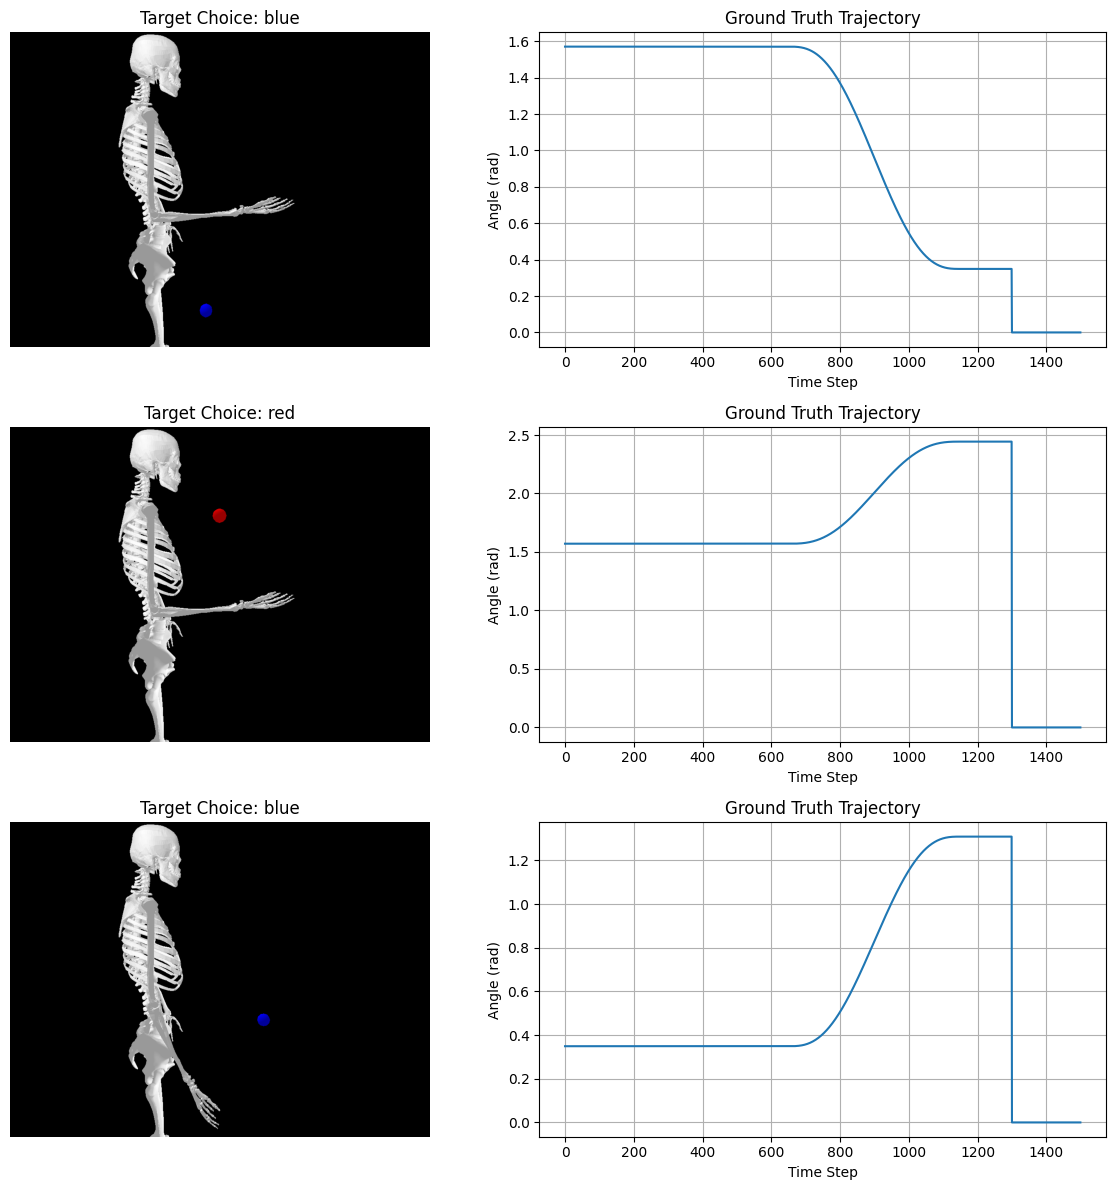

In [37]:
# Reproduces one cell of the imagedata_gen.py sweep, e.g. filename "90_20_blue.bmp"
angles = [(90, 20), (90, 140), (20, 75)]
colours = ["red", "blue"]
sim_step = 1.0 # Simulation time step (ms)
time_prep_ms = 650.0
time_move_ms = 500.0
time_locked_with_feedback_ms = 150.0
time_post_ms = 100.0

task_data = {
    "imgs_path": [],
    "target_choice": [],
    "traj_target": []
}

# --- Visualize a few data samples --- #
print("\nVisualizing a few data samples...")
num_samples_to_show = len(angles)
fig, axes = plt.subplots(num_samples_to_show, 2, figsize=(12, 4 * num_samples_to_show))
if num_samples_to_show == 1: axes = [axes] # make it iterable

for i, couple in enumerate(angles):
    angle_in = couple[0]
    angle_end = couple[1]
    colour = random.choice(colours)
    img_name = str(angle_in) + "_" + str(angle_end) + "_" + colour + ".bmp"
    img_complete_path = Path("notebooks/imgs/" + img_name)

    # add to the dictionary the image path
    task_data["imgs_path"].append(img_complete_path)
    task_data["target_choice"].append(colour)

    if img_complete_path.exists():
        print("The capture of the robot already exists")
    else:
        render_scene(init_angle_deg=angle_in, target_angle_deg=angle_end, color_label=colour,
                    image_path=img_complete_path)

    angle_in_rad = math.radians(angle_in)
    angle_end_rad = math.radians(angle_end)

    minjerk = MinJerkTrajectoryGenerator(params)
    target_traj = minjerk.angles_to_trajectory(angle_in_rad, angle_end_rad)

    # add to the dictionary the generated trajectory (ground truth)
    task_data["traj_target"].append(target_traj)

    # Plot image
    image = Image.open(img_complete_path)
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"Target Choice: {colour}")
    axes[i, 0].axis('off')

    # Plot trajectory
    axes[i, 1].plot(target_traj)
    axes[i, 1].set_title("Ground Truth Trajectory")
    axes[i, 1].set_xlabel("Time Step")
    axes[i, 1].set_ylabel("Angle (rad)")
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

--- Setting up Evaluation for GLE Planner ---
Loading planner (vision net + trajectory generator) from: submodules/pfc_planner/models
2026-09-26 13:39:45 [warning  ] Loading GLE trajectory generator from submodules/pfc_planner/models/trained_gle_trajectory_generator.pth
Loading vision network from submodules/pfc_planner/models/trained_gle_planner.pth to device 'cpu'...

Generating predictions and calculating accuracy...
Comparing final angles at index: -200
Sample 0: 1405/1500 points within 1° (93.7%)
Sample 1: 1328/1500 points within 1° (88.5%)
Sample 2: 926/1500 points within 1° (61.7%)


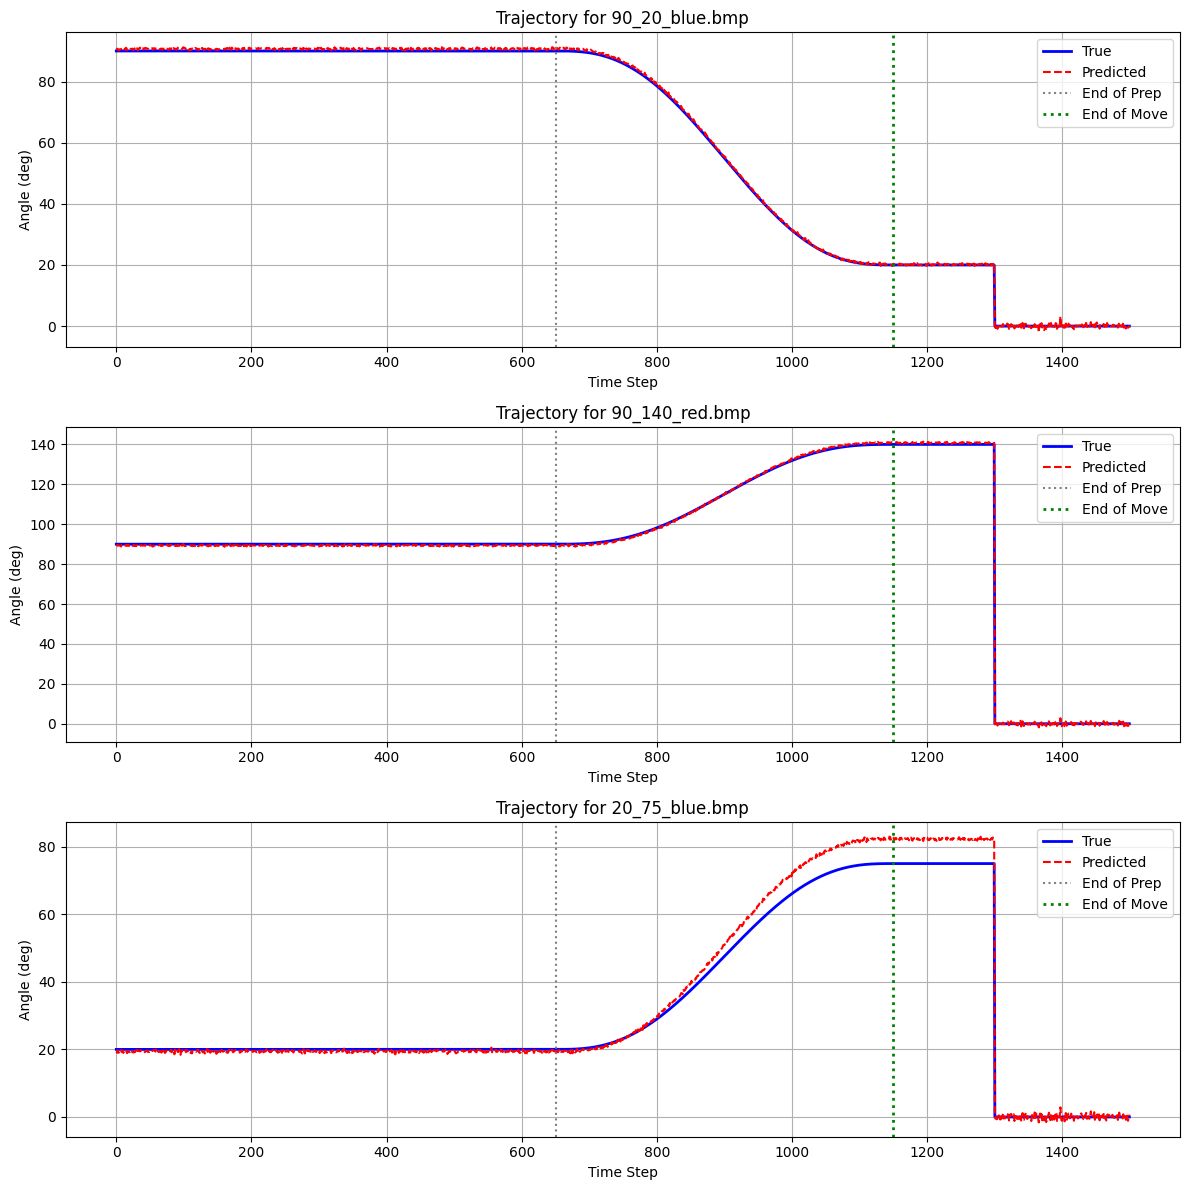


--- Evaluation Complete ---
Choice Accuracy: 0.00%
Final Angle Accuracy (within 1.0°): 100.00%


In [45]:
print(f"--- Setting up Evaluation for {params.model_type.upper()} Planner ---")

model_path = PLANNER_MODEL_DIR / "trained_gle_planner.pth"
if not model_path.exists():
    raise FileNotFoundError(f"ERROR: Model not found at {model_path}. Please train it first.")

print(f"Loading planner (vision net + trajectory generator) from: {PLANNER_MODEL_DIR}")
planner = get_planner(params, model_dir=PLANNER_MODEL_DIR)  # loads BOTH networks' pretrained weights

print("\nGenerating predictions and calculating accuracy...")

post_phase_steps = int((params.time_grasp + params.time_post) / params.resolution)
angle_comparison_index = -post_phase_steps if post_phase_steps > 0 else -1
print(f"Comparing final angles at index: {angle_comparison_index}")

time_prep_steps = int(params.time_prep / params.resolution)
time_move_end_steps = int((params.time_prep + params.time_move) / params.resolution)

correct_choices = 0
correct_angles = 0
predicted_trajectories = []

num_samples = len(task_data["imgs_path"])
fig, axes = plt.subplots(num_samples, 1, figsize=(12, 4 * num_samples), squeeze=False)
axes = axes[:, 0]  # flatten the (num_samples, 1) column into a 1-D array of Axes

for i in range(num_samples):
    image_path = task_data["imgs_path"][i]
    true_trajectory = task_data["traj_target"][i]

    predicted_trajectory, predicted_choice = planner.image_to_trajectory(image_path)
    predicted_trajectories.append(predicted_trajectory)

    if predicted_choice == task_data["target_choice"][i]:
        correct_choices += 1

    if np.isclose(predicted_trajectory[angle_comparison_index],
                   true_trajectory[angle_comparison_index],
                   atol=np.deg2rad(1.0)):
        correct_angles += 1

    close_pts = np.isclose(predicted_trajectory, true_trajectory, atol=np.deg2rad(1.0))
    print(f"Sample {i}: {np.sum(close_pts)}/{len(close_pts)} points within 1° "
          f"({100 * np.mean(close_pts):.1f}%)")

    ax = axes[i]
    ax.plot(np.rad2deg(true_trajectory), label="True", color="blue", linewidth=2)
    ax.plot(np.rad2deg(predicted_trajectory), label="Predicted", color="red", linestyle="--")
    ax.axvline(time_prep_steps, color="gray", linestyle=":", linewidth=1.5, label="End of Prep")
    ax.axvline(time_move_end_steps, color="green", linestyle=":", linewidth=2, label="End of Move")
    ax.set_title(f"Trajectory for {Path(image_path).name}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Angle (deg)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

choice_accuracy = 100 * correct_choices / num_samples
angle_accuracy = 100 * correct_angles / num_samples
print(f"\n--- Evaluation Complete ---")
print(f"Choice Accuracy: {choice_accuracy:.2f}%")
print(f"Final Angle Accuracy (within 1.0°): {angle_accuracy:.2f}%")

# Motor Cortex (M1)

In this section it is introduced the Motor Conrtex Model: a recurrent spiking neural network inspired by the **primary motor cortex (M1)** that learns to transform desired reaching trajectories into motor commands.

# Cerebellum

# The whole controller